In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [4]:
df.tail()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
249995,33308,2023-08-10 13:39:06,Clothing,279,2,2187,PayPal,55,1.0,Michelle Flores,55,Male,1
249996,48835,2021-11-23 01:30:42,Home,27,1,3615,Credit Card,42,1.0,Jeremy Rush,42,Female,1
249997,21019,2020-07-02 14:04:48,Home,17,5,2466,Cash,41,0.0,Tina Craig,41,Male,0
249998,49234,2020-12-30 02:02:40,Books,398,2,3668,Crypto,34,0.0,Jennifer Cooper,34,Female,1
249999,16971,2021-03-13 16:28:35,Electronics,425,4,2370,Cash,36,1.0,Justin Lawson,36,Female,1


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 250000
Columns : 13


In [6]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 24.8 MB


In [8]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [9]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

In [13]:
df.drop(columns=["Customer Age"], inplace=True)

In [14]:
df["Month"] = df["Purchase Date"].dt.month_name()

df["Year"] = df["Purchase Date"].dt.year

df["Day"] = df["Purchase Date"].dt.day_name()

In [15]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Returns,Customer Name,Age,Gender,Churn,Month,Year,Day
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,0.0,Christine Hernandez,37,Male,0,September,2020,Tuesday
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,0.0,Christine Hernandez,37,Male,0,March,2022,Saturday
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,0.0,Christine Hernandez,37,Male,0,May,2022,Monday
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,0.0,Christine Hernandez,37,Male,0,November,2020,Thursday
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,0.0,James Grant,49,Female,1,November,2020,Friday


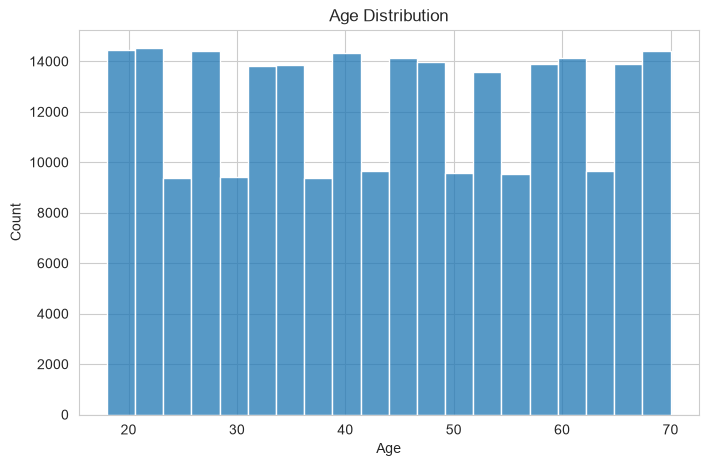

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

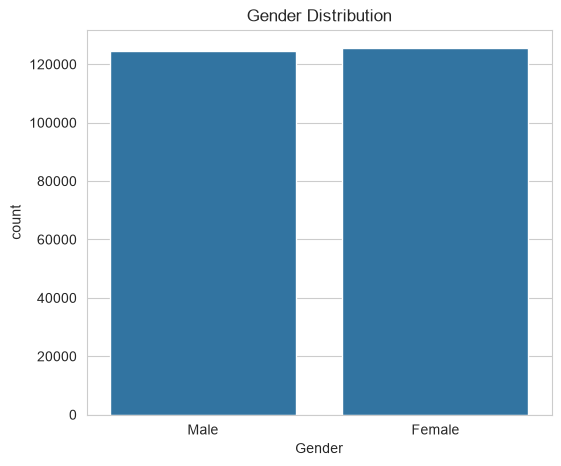

In [17]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Gender")

plt.title("Gender Distribution")

plt.show()

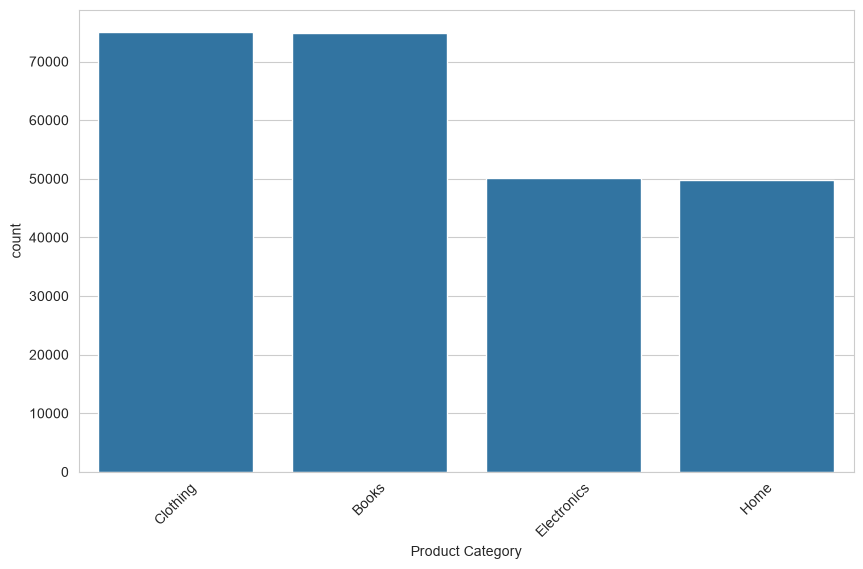

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Product Category",
    order=df["Product Category"].value_counts().index
)

plt.xticks(rotation=45)

plt.show()

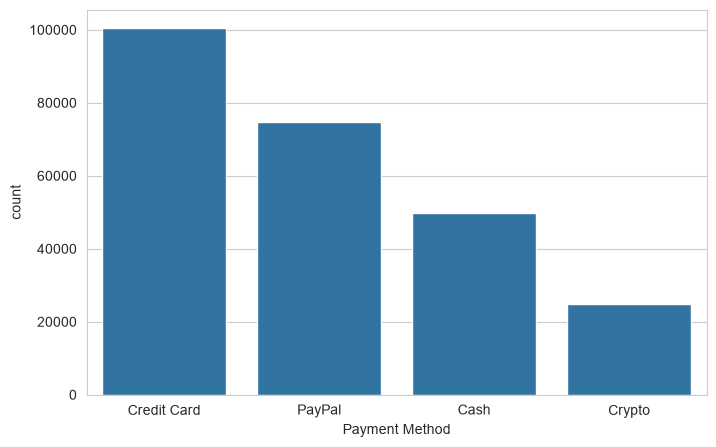

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Payment Method")

plt.show()

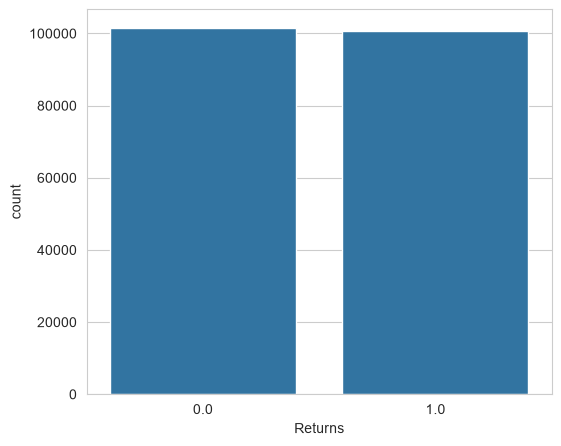

In [20]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Returns")

plt.show()

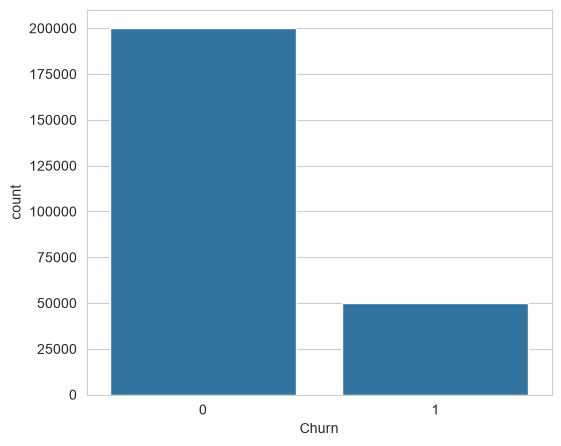

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Churn")

plt.show()

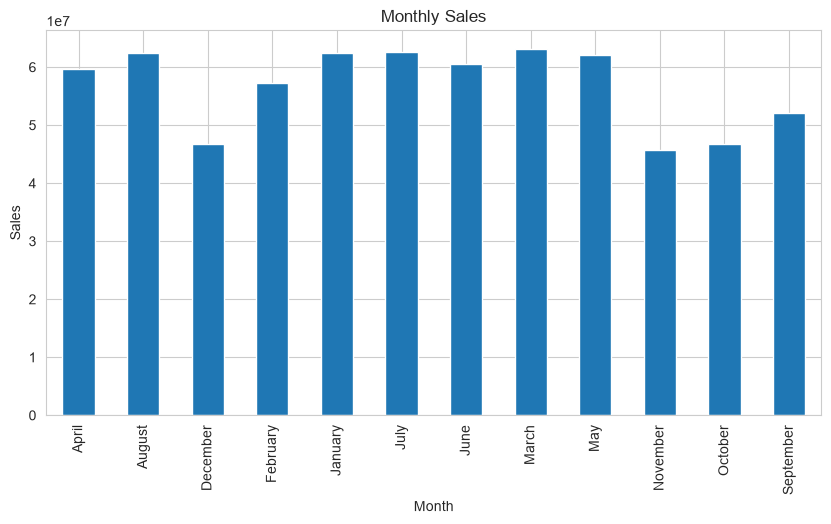

In [22]:
monthly_sales = df.groupby("Month")["Total Purchase Amount"].sum()

monthly_sales.plot(kind="bar", figsize=(10,5))

plt.ylabel("Sales")

plt.title("Monthly Sales")

plt.show()

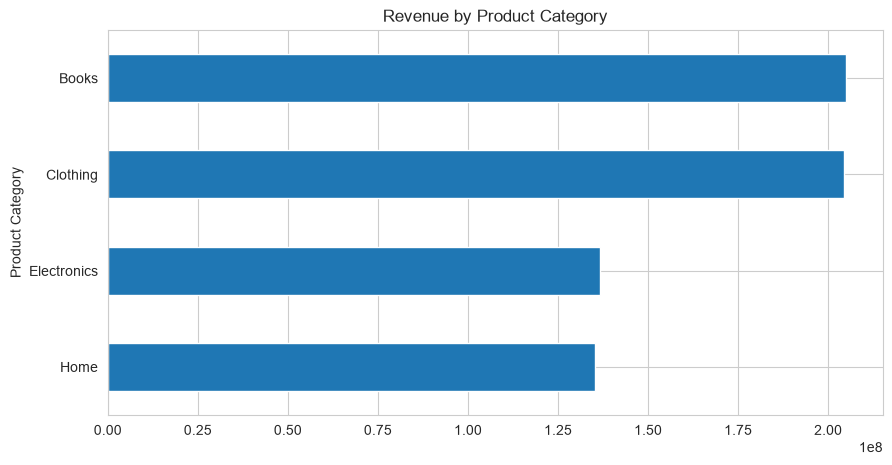

In [23]:
category_sales = df.groupby("Product Category")["Total Purchase Amount"].sum()

category_sales.sort_values().plot(kind="barh", figsize=(10,5))

plt.title("Revenue by Product Category")

plt.show()

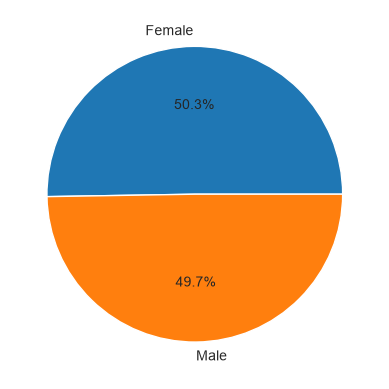

In [24]:
gender_sales = df.groupby("Gender")["Total Purchase Amount"].sum()

gender_sales.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.show()

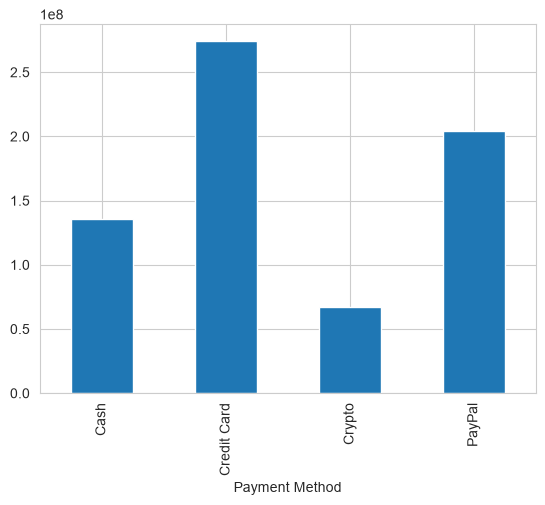

In [25]:
payment = df.groupby("Payment Method")["Total Purchase Amount"].sum()

payment.plot(kind="bar")

plt.show()

In [26]:
today = df["Purchase Date"].max()

rfm = df.groupby("Customer ID").agg({

    "Purchase Date": lambda x:(today-x.max()).days,

    "Customer ID":"count",

    "Total Purchase Amount":"sum"

})

rfm.columns=["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,3491
2,298,3,7988
3,88,8,22587
4,126,4,8715
5,170,8,12524


In [27]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [28]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [29]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,135.843843,8.440577,24494.153654
1,182.652246,5.715804,15614.061368
2,193.014351,3.332216,8292.908731
3,718.847954,2.939600,7825.245392


In [30]:
rfm["Cluster"].value_counts()

Cluster
1    18723
2    14912
0     8389
3     7649
Name: count, dtype: int64

In [31]:
pd.crosstab(df["Gender"],df["Churn"])

Churn,0,1
Gender,,
Female,100920,24640
Male,99206,25234


In [32]:
pd.crosstab(df["Product Category"],df["Churn"])

Churn,0,1
Product Category,,
Books,59986,14926
Clothing,60154,14898
Electronics,40206,9979
Home,39780,10071


In [33]:
pd.crosstab(df["Payment Method"],df["Churn"])

Churn,0,1
Payment Method,,
Cash,39913,9981
Credit Card,80402,20084
Crypto,19857,4926
PayPal,59954,14883


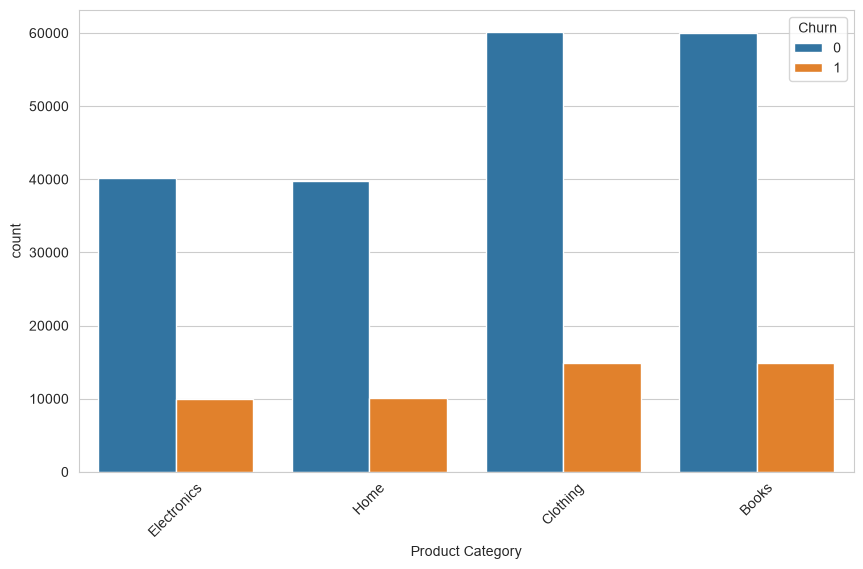

In [34]:
plt.figure(figsize=(10,6))

sns.countplot(data=df,x="Product Category",hue="Churn")

plt.xticks(rotation=45)

plt.show()

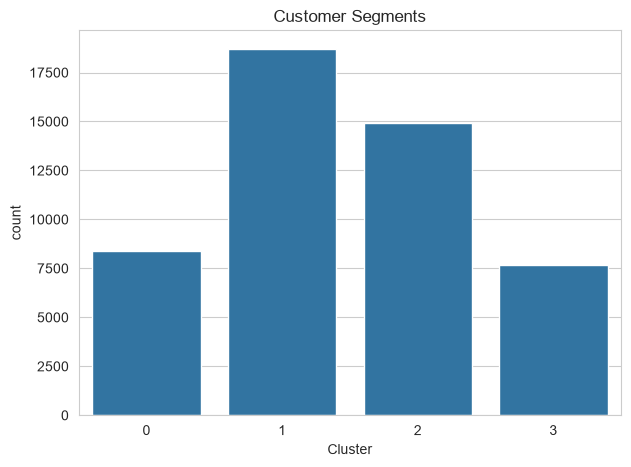

In [35]:
plt.figure(figsize=(7,5))

sns.countplot(x=rfm["Cluster"])

plt.title("Customer Segments")

plt.show()

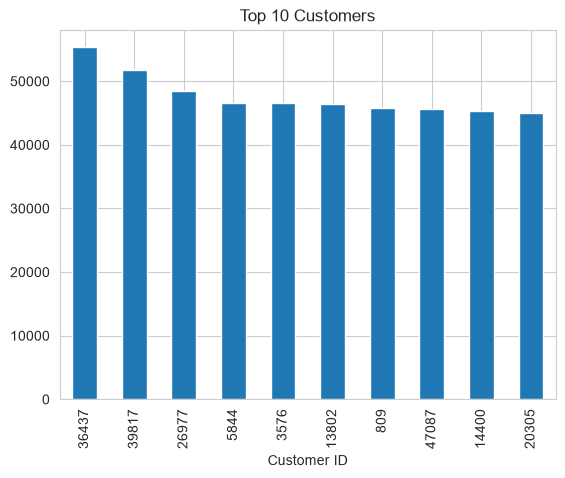

In [36]:
top = df.groupby("Customer ID")["Total Purchase Amount"].sum().sort_values(ascending=False).head(10)

top.plot(kind="bar")

plt.title("Top 10 Customers")

plt.show()

Key Findings

• Electronics generated the highest revenue.

• Customers aged 25–40 made the most purchases.

• Credit Card was the most preferred payment method.

• Cluster 2 contained the highest-value customers.

• Customers with low purchase frequency had a higher churn rate.

Recommendations

1. Launch a loyalty rewards program for frequent customers.

2. Offer personalized discounts to customers likely to churn.

3. Improve quality control for products with high return rates.

4. Increase promotions for the best-selling product categories.

5. Encourage digital payments through cashback offers.

Conclusion

The customer behavior analysis identified key purchasing trends, customer segments, and churn patterns. Through data cleaning, exploratory data analysis, and RFM-based customer segmentation using K-Means clustering, valuable insights were obtained. The findings can help Alfido Tech improve customer retention, personalize marketing strategies, and increase overall business performance.